# 01 — Replication: Lost in the Middle (Wikipedia 2024-2025 Dataset)

Replicate the Liu et al. (2023) "Lost in the Middle" U-shaped curve using our
custom dataset built from post-October 2023 Wikipedia articles.

- **Dataset:** 196 questions from recent events (Oscars, Olympics, Nobel Prizes, etc.)
- **Design:** 20 documents per prompt, gold doc swept across positions 1, 5, 10, 15, 20
- **Within-subjects:** every question tested at every position
- **196 questions × 5 positions = 980 API calls**
- No preamble, temperature 0

**Why a new dataset?** The TriviaQA-based dataset suffered from parametric memory
contamination — GPT-4o-mini already knows many of those answers. This dataset uses
events after the model's training cutoff, forcing it to rely on the provided documents.

In [3]:
import sys, os, json, random
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

from litm.prompts import build_context, format_prompt
from litm.scoring import score
from litm.api import get_client, query_model

In [2]:
# Load the Wikipedia 2024-2025 dataset
with open("../DatasetBuilder/dataset/final_dataset.json", "r", encoding="utf-8") as f:
    questions = json.load(f)

print(f"Loaded {len(questions)} questions")
print(f"Distractors per question: {len(questions[0]['distractors'])}")
print(f"Domains: {set(q['gold_article'] for q in questions)}")
print(f"\nSample question: {questions[0]['question']}")
print(f"Sample answer: {questions[0]['answer']} (aliases: {questions[0]['answer_aliases']})")

Loaded 196 questions
Distractors per question: 19
Domains: {'Nobel Prize in Physiology or Medicine', '2025 in literature', '2024 Nobel Prizes', 'Nobel Prize in Physics', '66th Annual Grammy Awards', '2024 United States presidential election', 'UEFA Euro 2024', '67th Annual Grammy Awards', '2024 Pulitzer Prize', '2024 in Music', '2024 FIFA Intercontinental Cup', '2024 Booker Prize', '2024 Wimbledon Championships', '2025 Australian Open', '2024 Summer Olympics', '77th British Academy Film Awards', '98th Academy Awards', '82nd Golden Globe Awards', '97th Academy Awards', '2025 in Film', '2025 in politics', '2024 in Film', '78th British Academy Film Awards', '81st Golden Globe Awards', '2024 Tour de France'}

Sample question: Who hosted the 97th Academy Awards ceremony?
Sample answer: Conan O'Brien (aliases: ["Conan O'Brien", "O'Brien", "conan o'brien"])


## Run Experiment

Every question is tested at all 5 gold positions (within-subjects design).
Distractors are re-sampled per trial so the model can't memorize context patterns.

Results are checkpointed every 50 questions so we can resume if interrupted.

In [3]:
client, model = get_client("gpt-4o-mini")

POSITIONS = [0, 4, 9, 14, 19]  # 0-indexed (displayed as 1, 5, 10, 15, 20)
TOTAL_DOCS = 20
CHECKPOINT_PATH = "../results/exp0_wiki_checkpoint.csv"
RESULTS_PATH = "../results/exp0_wiki_replication.csv"

print(f"Model: {model}")
print(f"{len(questions)} questions × {len(POSITIONS)} positions = {len(questions) * len(POSITIONS)} API calls")

Model: gpt-4o-mini
196 questions × 5 positions = 980 API calls


In [4]:
# Resume from checkpoint if available
completed = set()
results = []

if os.path.exists(CHECKPOINT_PATH):
    prev = pd.read_csv(CHECKPOINT_PATH)
    results = prev.to_dict("records")
    completed = {(r["question_id"], r["gold_position"]) for r in results}
    print(f"Resuming from checkpoint: {len(results)} trials already done")
else:
    print("Starting fresh — no checkpoint found")

os.makedirs("../results", exist_ok=True)

for qi, q in enumerate(tqdm(questions, desc="Questions")):
    for pos in POSITIONS:
        pos_label = pos + 1  # 1-indexed for display

        if (q["id"], pos_label) in completed:
            continue

        # Re-seed per (question, position) so distractors vary but are reproducible
        random.seed(42 + qi * 100 + pos)
        docs = build_context(q["gold_passage"], q["distractors"], pos, TOTAL_DOCS)
        prompt = format_prompt(docs, q["question"])
        response = query_model(client, model, prompt)
        correct = score(response, q["answer_aliases"])

        results.append({
            "question_id": q["id"],
            "question": q["question"],
            "expected": q["answer"],
            "response": response,
            "correct": correct,
            "gold_position": pos_label,
        })

    # Checkpoint every 50 questions
    if (qi + 1) % 50 == 0:
        pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)
        print(f"  Checkpoint saved at question {qi + 1}")

df = pd.DataFrame(results)
df.to_csv(RESULTS_PATH, index=False)
print(f"\nTotal trials: {len(df)}")
print(f"Overall accuracy: {df['correct'].mean():.1%}")
print(f"Saved to {RESULTS_PATH}")

Starting fresh — no checkpoint found


Questions:   0%|          | 0/196 [00:00<?, ?it/s]

  Checkpoint saved at question 50
  Checkpoint saved at question 100
  Checkpoint saved at question 150

Total trials: 980
Overall accuracy: 76.7%
Saved to ../results/exp0_wiki_replication.csv


## Plot: Accuracy by Gold Document Position

Expecting a U-shaped curve: high at positions 1 and 20, degraded in the middle.

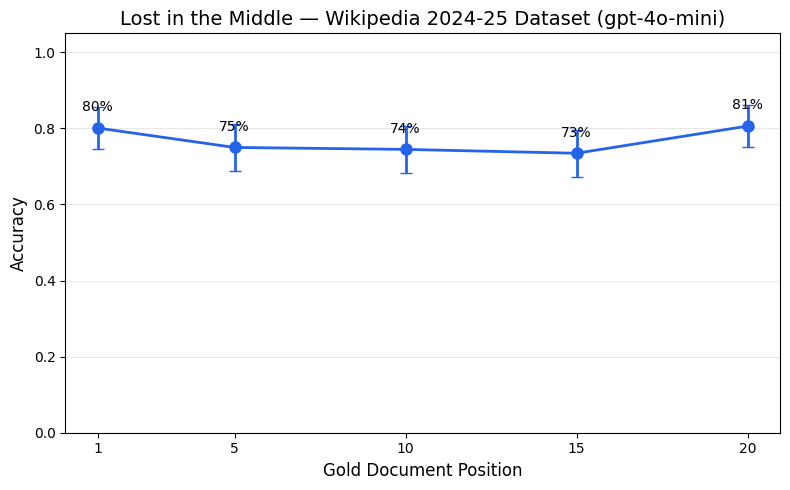


Accuracy by position:
  Position  1: 80% (157/196)
  Position  5: 75% (147/196)
  Position 10: 74% (146/196)
  Position 15: 73% (144/196)
  Position 20: 81% (158/196)


In [5]:
# If loading from saved results instead of re-running:
# df = pd.read_csv("../results/exp0_wiki_replication.csv")

acc_by_pos = df.groupby("gold_position")["correct"].agg(["mean", "count", "sum"])
acc_by_pos["se"] = (acc_by_pos["mean"] * (1 - acc_by_pos["mean"]) / acc_by_pos["count"]) ** 0.5

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    acc_by_pos.index, acc_by_pos["mean"],
    yerr=1.96 * acc_by_pos["se"],
    marker="o", linewidth=2, markersize=8, capsize=4, color="#2563eb"
)
ax.set_xlabel("Gold Document Position", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title(f"Lost in the Middle — Wikipedia 2024-25 Dataset ({model})", fontsize=14)
ax.set_xticks(acc_by_pos.index)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)

for pos, row in acc_by_pos.iterrows():
    ax.annotate(f"{row['mean']:.0%}", (pos, row["mean"]),
                textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../results/exp0_wiki_u_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAccuracy by position:")
for pos, row in acc_by_pos.iterrows():
    print(f"  Position {pos:2d}: {row['mean']:.0%} ({int(row['sum'])}/{int(row['count'])})")

## Accuracy by Domain

Check whether the U-shape is consistent across topic domains or driven by a specific subset.

In [6]:
# Map question IDs to their source article/domain
q_to_article = {q["id"]: q["gold_article"] for q in questions}
df["domain"] = df["question_id"].map(q_to_article)

domain_pos = df.groupby(["domain", "gold_position"])["correct"].mean().unstack()
print("Accuracy by domain × position:\n")
print(domain_pos.round(2).to_string())

# Per-domain U-effect
print("\nU-effect by domain:")
for domain in domain_pos.index:
    row = domain_pos.loc[domain]
    edge = (row.get(1, 0) + row.get(20, 0)) / 2
    mid = (row.get(5, 0) + row.get(10, 0) + row.get(15, 0)) / 3
    n = len(df[(df["domain"] == domain)])
    print(f"  {domain:<45s} edge={edge:.0%}  mid={mid:.0%}  effect={edge-mid:+.0%}  (n={n})")

Accuracy by domain × position:

gold_position                               1     5     10    15    20
domain                                                                
2024 Booker Prize                         0.62  0.75  0.88  0.88  0.75
2024 FIFA Intercontinental Cup            0.78  0.33  0.56  0.67  0.78
2024 Nobel Prizes                         0.80  0.90  0.90  0.90  0.90
2024 Pulitzer Prize                       0.50  0.00  0.50  0.50  0.50
2024 Summer Olympics                      1.00  1.00  1.00  1.00  1.00
2024 Tour de France                       0.90  0.90  0.90  1.00  1.00
2024 United States presidential election  0.89  0.89  0.78  1.00  1.00
2024 Wimbledon Championships              1.00  1.00  1.00  1.00  1.00
2024 in Film                              1.00  0.78  0.56  0.67  0.78
2024 in Music                             0.70  0.80  0.80  0.60  1.00
2025 Australian Open                      0.50  0.50  0.50  0.50  0.62
2025 in Film                              1.0

## Gate Check

Does the U-curve look right? Verify before proceeding to Experiments 1–3.

In [7]:
edge_acc = acc_by_pos.loc[[1, 20], "mean"].mean()
middle_acc = acc_by_pos.loc[[5, 10, 15], "mean"].mean()
u_effect = edge_acc - middle_acc

print(f"Edge accuracy (pos 1, 20):    {edge_acc:.1%}")
print(f"Middle accuracy (pos 5,10,15): {middle_acc:.1%}")
print(f"U-curve effect size:           {u_effect:+.1%}")
print(f"Total questions:               {len(questions)}")
print(f"Total trials:                  {len(df)}")

if u_effect > 0.10:
    print("\n✓ Gate PASSED — clear U-shape detected. Proceed to Experiments 1–3.")
elif u_effect > 0.05:
    print("\n~ Marginal U-shape. Results may be noisy. Consider increasing N or using a weaker model.")
else:
    print("\n✗ Gate FAILED — no meaningful U-shape. Debug before continuing.")
    print("  Possible causes: model too strong, distractors too easy/hard, scoring issues.")

Edge accuracy (pos 1, 20):    80.4%
Middle accuracy (pos 5,10,15): 74.3%
U-curve effect size:           +6.0%
Total questions:               196
Total trials:                  980

~ Marginal U-shape. Results may be noisy. Consider increasing N or using a weaker model.


## Spot Check: Sample Incorrect Responses

Manual inspection of wrong answers to catch scoring false negatives
(model got the right answer but phrased differently than any alias).

In [8]:
wrong = df[~df["correct"]].sample(min(15, (~df["correct"]).sum()), random_state=42)
for _, row in wrong.iterrows():
    print(f"Q: {row['question']}")
    print(f"  Expected: {row['expected']}")
    print(f"  Got:      {row['response']}")
    print(f"  Position: {row['gold_position']}")
    print()

Q: As of 2025, how many people have been awarded the Nobel Prize in Physics?
  Expected: 229
  Got:      I don't know.
  Position: 5

Q: Who announced the nominees for the 77th British Academy Film Awards?
  Expected: Naomi Ackie and Kingsley Ben-Adir
  Got:      I don't know.
  Position: 5

Q: Who became the first member of Generation Z to win an acting Oscar at the 97th Academy Awards?
  Expected: Mikey Madison
  Got:      I don't know.
  Position: 20

Q: Who was the first Native American author ever to be longlisted for the Booker Prize?
  Expected: Tommy Orange
  Got:      I don't know.
  Position: 15

Q: Who received the Jean Hersholt Humanitarian Award at the 97th Academy Awards' Governors Awards?
  Expected: Richard Curtis
  Got:      I don't know.
  Position: 10

Q: Who was the first Native American author ever to be longlisted for the Booker Prize?
  Expected: Tommy Orange
  Got:      I don't know.
  Position: 1

Q: Who became the first Brazilian nominated for Best Actor in a 

## Per-Question Analysis

Identify questions that are always correct or always wrong regardless of position
(these don't contribute to the positional effect and may indicate scoring or difficulty issues).

Always correct (all 5 positions):  106 (54%)
Always wrong (all 5 positions):    15 (8%)
Position-sensitive (mixed):        75 (38%)
Total questions:                   196


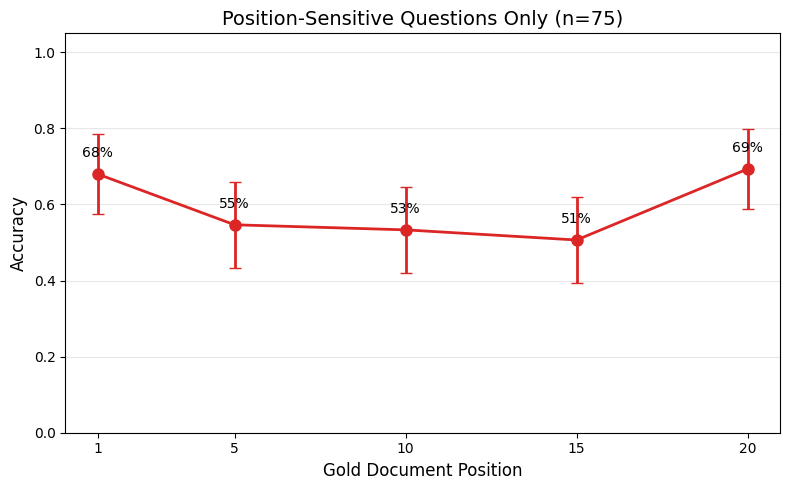


Mixed-only: edge=69%, middle=53%, effect=+16%


In [9]:
q_stats = df.groupby("question_id")["correct"].agg(["sum", "count"])
always_right = (q_stats["sum"] == q_stats["count"]).sum()
always_wrong = (q_stats["sum"] == 0).sum()
mixed = len(q_stats) - always_right - always_wrong

print(f"Always correct (all 5 positions):  {always_right} ({always_right/len(q_stats):.0%})")
print(f"Always wrong (all 5 positions):    {always_wrong} ({always_wrong/len(q_stats):.0%})")
print(f"Position-sensitive (mixed):        {mixed} ({mixed/len(q_stats):.0%})")
print(f"Total questions:                   {len(q_stats)}")

# The U-shape signal comes entirely from the "mixed" questions.
# Re-plot with only position-sensitive questions:
if mixed > 20:
    mixed_ids = q_stats[(q_stats["sum"] > 0) & (q_stats["sum"] < q_stats["count"])].index
    df_mixed = df[df["question_id"].isin(mixed_ids)]

    acc_mixed = df_mixed.groupby("gold_position")["correct"].agg(["mean", "count", "sum"])
    acc_mixed["se"] = (acc_mixed["mean"] * (1 - acc_mixed["mean"]) / acc_mixed["count"]) ** 0.5

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(
        acc_mixed.index, acc_mixed["mean"],
        yerr=1.96 * acc_mixed["se"],
        marker="o", linewidth=2, markersize=8, capsize=4, color="#dc2626"
    )
    ax.set_xlabel("Gold Document Position", fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=12)
    ax.set_title(f"Position-Sensitive Questions Only (n={mixed})", fontsize=14)
    ax.set_xticks(acc_mixed.index)
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

    for pos, row in acc_mixed.iterrows():
        ax.annotate(f"{row['mean']:.0%}", (pos, row["mean"]),
                    textcoords="offset points", xytext=(0, 12), ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig("../results/exp0_wiki_u_curve_mixed_only.png", dpi=150, bbox_inches="tight")
    plt.show()

    edge_m = acc_mixed.loc[[1, 20], "mean"].mean()
    mid_m = acc_mixed.loc[[5, 10, 15], "mean"].mean()
    print(f"\nMixed-only: edge={edge_m:.0%}, middle={mid_m:.0%}, effect={edge_m - mid_m:+.0%}")

## Clean Up Checkpoint

Remove the checkpoint file if the experiment completed successfully.

In [10]:
if os.path.exists(CHECKPOINT_PATH) and len(df) == len(questions) * len(POSITIONS):
    os.remove(CHECKPOINT_PATH)
    print("Checkpoint removed — experiment complete.")
else:
    print(f"Keeping checkpoint ({len(df)}/{len(questions) * len(POSITIONS)} trials done)")

Checkpoint removed — experiment complete.


In [4]:
df = pd.read_csv("../results/exp0_wiki_replication.csv")                                                                                                                                                  
model = "gpt-4o-mini"                     
acc_by_pos = df.groupby("gold_position")["correct"].agg(["mean", "count", "sum"])                                                                                                                         
acc_by_pos["se"] = (acc_by_pos["mean"] * (1 - acc_by_pos["mean"]) / acc_by_pos["count"]) ** 0.5

In [6]:
from scipy.stats import chi2, chi2_contingency
                                                                                                                                                                                                            
positions = sorted(df['gold_position'].unique())
pivot = df.pivot(index='question_id', columns='gold_position', values='correct').astype(int)                                                                                                              
k = len(positions)                                           

# 1. Cochran Q test (within-subjects omnibus)
col_sums = pivot.sum(axis=0)
row_sums = pivot.sum(axis=1)
T = row_sums.sum()
Q = ((k - 1) * (k * (col_sums**2).sum() - T**2)) / (k * T - (row_sums**2).sum())
p_cochran = 1 - chi2.cdf(Q, k - 1)
print(f"Cochran Q test: Q={Q:.3f}, df={k-1}, p={p_cochran:.6f}")

# 2. Chi-squared test of independence
contingency = pd.crosstab(df['gold_position'], df['correct'])
chi2_val, p_chi2, dof, _ = chi2_contingency(contingency)
print(f"Chi-squared:    χ²={chi2_val:.3f}, df={dof}, p={p_chi2:.6f}")

# 3. McNemar pairwise: each edge vs worst middle position
worst_mid = df[df['gold_position'].isin([5, 10, 15])].groupby('gold_position')['correct'].mean().idxmin()
print(f"\nMcNemar tests (vs worst middle = position {worst_mid}):")
for edge_pos in [1, 20]:
    b = ((pivot[edge_pos] == 1) & (pivot[worst_mid] == 0)).sum()
    c = ((pivot[edge_pos] == 0) & (pivot[worst_mid] == 1)).sum()
    stat = (abs(b - c) - 1)**2 / (b + c) if b + c > 0 else 0
    p = 1 - chi2.cdf(stat, 1) if b + c > 0 else 1.0
    print(f"  Pos {edge_pos:2d} vs {worst_mid}: edge_only={b}, mid_only={c}, χ²={stat:.3f}, p={p:.6f}")

# 4. Summary table
print(f"\nEdge accuracy (1, 20):      {acc_by_pos.loc[[1, 20], 'mean'].mean():.1%}")
print(f"Middle accuracy (5, 10, 15): {acc_by_pos.loc[[5, 10, 15], 'mean'].mean():.1%}")
print(f"U-effect:                     {acc_by_pos.loc[[1, 20], 'mean'].mean() - acc_by_pos.loc[[5, 10, 15], 'mean'].mean():+.1%}")

Cochran Q test: Q=9.413, df=4, p=0.051565
Chi-squared:    χ²=4.950, df=4, p=0.292483

McNemar tests (vs worst middle = position 15):
  Pos  1 vs 15: edge_only=27, mid_only=14, χ²=3.512, p=0.060919
  Pos 20 vs 15: edge_only=26, mid_only=12, χ²=4.447, p=0.034955

Edge accuracy (1, 20):      80.4%
Middle accuracy (5, 10, 15): 74.3%
U-effect:                     +6.0%
